In [10]:
from datasets import load_dataset, DatasetDict

hf_nature_ds = load_dataset("mertcobanov/nature-dataset")
split = hf_nature_ds["train"].train_test_split(test_size=0.2, seed=42)
hf_nature_ds = DatasetDict({
    "train": split["train"],
    "validation": split["test"]
})
hf_nature_ds

DatasetDict({
    train: Dataset({
        features: ['image', 'caption'],
        num_rows: 40000
    })
    validation: Dataset({
        features: ['image', 'caption'],
        num_rows: 10000
    })
})

In [11]:
from datasets import load_dataset, DatasetDict

# Re-load the dataset to ensure 'caption' column is present,
# in case it was removed in a previous execution of this cell.
original_hf_nature_ds = load_dataset("mertcobanov/nature-dataset")
split = original_hf_nature_ds["train"].train_test_split(test_size=0.2, seed=42)
hf_nature_ds_reloaded = DatasetDict({
    "train": split["train"],
    "validation": split["test"]
})

NOT_TRAVERSIBLE_KEYWORDS = {
    # Water
    "water", "ocean", "river", "lake", "stream", "pond",
    "waterfall", "flood", "swamp", "marsh", "sea",
    # Hazardous terrain
    "cliff", "steep", "ravine", "gorge", "canyon",
    "chasm", "precipice",
    # Dense vegetation
    "thicket", "bramble",
    # Other
    "lava", "quicksand", "mud", "snow", "ice", "glacier",
}

def label_traversibility(example):
    caption = example["caption"].lower()
    # Tokenize on word boundaries to avoid partial matches
    words = set(caption.replace(",", " ").replace(".", " ").split())
    is_not_traversible = bool(words & NOT_TRAVERSIBLE_KEYWORDS)
    return {"label": 0 if is_not_traversible else 1}

# Use the reloaded dataset for mapping
hf_nature_ds = hf_nature_ds_reloaded.map(label_traversibility)
hf_nature_ds = hf_nature_ds.remove_columns(["caption"])
train_labels = hf_nature_ds["train"]["label"]
validation_labels = hf_nature_ds["validation"]["label"]
hf_nature_ds, train_labels[1]

(DatasetDict({
     train: Dataset({
         features: ['image', 'label'],
         num_rows: 40000
     })
     validation: Dataset({
         features: ['image', 'label'],
         num_rows: 10000
     })
 }),
 0)

In [12]:
import os
import tensorflow as tf
from tensorflow.data import Dataset as TFDataset
num_cpus = os.cpu_count() if os.cpu_count() is not None else 1
# Now, split into training and validation tensorflow datasets
train_nature_ds: TFDataset = hf_nature_ds["train"].to_tf_dataset(
    columns="image",
    label_cols="label",
    batch_size=32,
    shuffle=True,
    num_workers=num_cpus
)
validation_nature_ds: TFDataset = hf_nature_ds["validation"].to_tf_dataset(
    columns="image",
    label_cols="label",
    batch_size=32,
    shuffle=False,
    num_workers=num_cpus
)
train_nature_ds, validation_nature_ds

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 512, 512, 3), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 512, 512, 3), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

In [4]:
# Cast all dataset image dtypes to be tf.uint8, which is the standard...
train_nature_ds: TFDataset = train_nature_ds.map(lambda img, lbl: (tf.cast(img, tf.uint8), lbl))
validation_nature_ds: TFDataset = validation_nature_ds.map(lambda img, lbl: (tf.cast(img, tf.uint8), lbl))
train_nature_ds, validation_nature_ds

(<_MapDataset element_spec=(TensorSpec(shape=(None, 512, 512, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_MapDataset element_spec=(TensorSpec(shape=(None, 512, 512, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

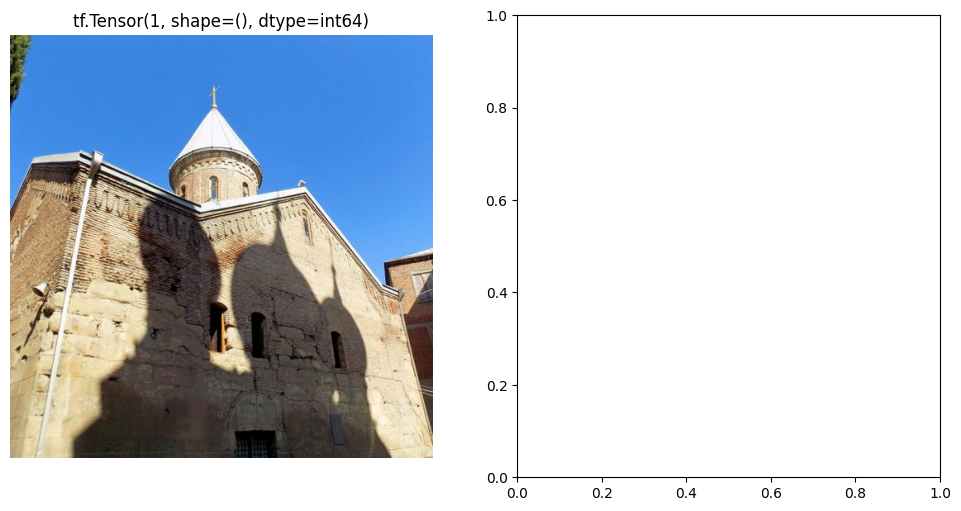

In [13]:
import matplotlib.pyplot as plt
image, label = next(iter(train_nature_ds.unbatch().take(1)))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original image
axes[0].imshow(image.numpy().astype("uint8"))
axes[0].set_title(label)
axes[0].axis("off")

plt.show()

In [20]:
import tensorflow as tf

# ---- Model ----------------------------------------------------------------

def make_tinyvgg(num_classes: int, input_shape: tuple = (64, 64, 3)) -> tf.keras.Model:
    return tf.keras.Sequential([
        # Block 1
        tf.keras.layers.Conv2D(10, 3, padding="same", activation="relu", input_shape=input_shape),
        tf.keras.layers.Conv2D(10, 3, padding="same", activation="relu"),
        tf.keras.layers.MaxPool2D(2),

        # Block 2
        tf.keras.layers.Conv2D(10, 3, padding="same", activation="relu"),
        tf.keras.layers.Conv2D(10, 3, padding="same", activation="relu"),
        tf.keras.layers.MaxPool2D(2),

        # Classifier
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ], name="TinyVGG")


# ---- Dataset conversion ---------------------------------------------------

def hf_split_to_tf(hf_split, image_size=(64, 64), batch_size=32, shuffle=False):
    """Convert a HuggingFace dataset split to a tf.data.Dataset."""

    def gen():
        for example in hf_split:
            img = example["image"].resize(image_size).convert("RGB")
            yield tf.keras.utils.img_to_array(img) / 255.0, example["label"]

    num_classes = 2
    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(*image_size, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(),              dtype=tf.int64),
        )
    )
    if shuffle:
        ds = ds.shuffle(1024)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE), num_classes


# ---- Training -------------------------------------------------------------

train_ds, num_classes = hf_split_to_tf(hf_nature_ds["train"],   shuffle=True)
val_ds,   _           = hf_split_to_tf(hf_nature_ds["validation"])

model = make_tinyvgg(num_classes=num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=["accuracy"],
)
model.summary()

history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Model: "TinyVGG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 10)     │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 64, 64, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         5,122 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,132 (31.77 KB)

 Trainable params: 8,132 (31.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
   1249/Unknown 252s 195ms/step - accuracy: 0.7097 - loss: 0.5747

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 309s 240ms/step - accuracy: 0.7097 - loss: 0.5746 - val_accuracy: 0.7534 - val_loss: 0.5128
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 303s 238ms/step - accuracy: 0.7591 - loss: 0.5078 - val_accuracy: 0.7714 - val_loss: 0.4888
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 299s 235ms/step - accuracy: 0.7760 - loss: 0.4818 - val_accuracy: 0.7830 - val_loss: 0.4717
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 301s 237ms/step - accuracy: 0.7844 - loss: 0.4698 - val_accuracy: 0.7775 - val_loss: 0.4835
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 307s 241ms/step - accuracy: 0.7904 - loss: 0.4555 - val_accuracy: 0.7878 - val_loss: 0.4706
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 303s 238ms/step - accuracy: 0.7971 - loss: 0.4460 - val_accuracy: 0.7882 - val_loss: 0.4733
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 303s 238ms/step - accuracy: 0.7986 - loss: 0.4401 - val_accuracy: 0.7901 - val_loss: 0.4636
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 304s 239ms/step - accuracy: 0.8